In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error
import os, csv

from helpers import load_data, preprocess, normalize, create_window, train_and_evaluate_models, \
    plot_performance, print_model_summaries, write_model_results_to_csv, WindowGenerator, \
    baseline, linear, dense, simple_rnn, cnn, lstm, autoregressive, bi_lstm, load_all_data, create_csv, \
    calculate_original_performance, drop_feature_and_evaluate, create_feature_csv, plot_training_history, compile_and_fit

2024-11-04 15:25:14.747243: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
df = pd.read_csv("./Station3_precipitation_chance.csv", index_col=0, parse_dates=True)
df = df[~df.index.duplicated(keep='first')]
#df = preprocess(df)
df = normalize(df)
df = df.drop(columns = ['SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20', 'T_50'])
df.head()
n = len(df)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]


In [3]:
window = create_window(
        input_width=24,
        label_width=1,
        shift=1,
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        label_columns=['Predicted_Rain_Next_Hour_1h', 'Predicted_Rain_Next_Hour_3h', 'Predicted_Rain_Next_Hour_6h', 'Predicted_Rain_Next_Hour_12h', 'Predicted_Rain_Next_Hour_24h']
    )

In [4]:
val_performance = {}
performance = {}
num_features = df.shape[1]
lstm_model = lstm(5, num_features)
history = compile_and_fit(lstm_model, window)

val_performance['Lstm'] = lstm_model.evaluate(window.val, return_dict=True)
performance['Lstm'] = lstm_model.evaluate(window.test, verbose=0, return_dict=True)

/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 1.0970 - mean_absolute_error: 0.3526 - val_loss: 0.6067 - val_mean_absolute_error: 0.2580
Epoch 2/20
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 1.0667 - mean_absolute_error: 0.3058 - val_loss: 0.6067 - val_mean_absolute_error: 0.2572
Epoch 3/20
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 1.0702 - mean_absolute_error: 0.3046 - val_loss: 0.6066 - val_mean_absolute_error: 0.2571
Epoch 4/20
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 1.0710 - mean_absolute_error: 0.3052 - val_loss: 0.6066 - val_mean_absolute_error: 0.2573
Epoch 5/20
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 1.0746 - mean_absolute_error: 0.3049 - val_loss: 0.6064 - val_mean_absolute_error: 0.2564
Epoch 6/20
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 1.0751 - mean_absolute_error: 0.3047 - val_loss: 0.6073 - val_mean_absolute_error: 0.2584
Epoch 7/20
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 1.0744 - mean

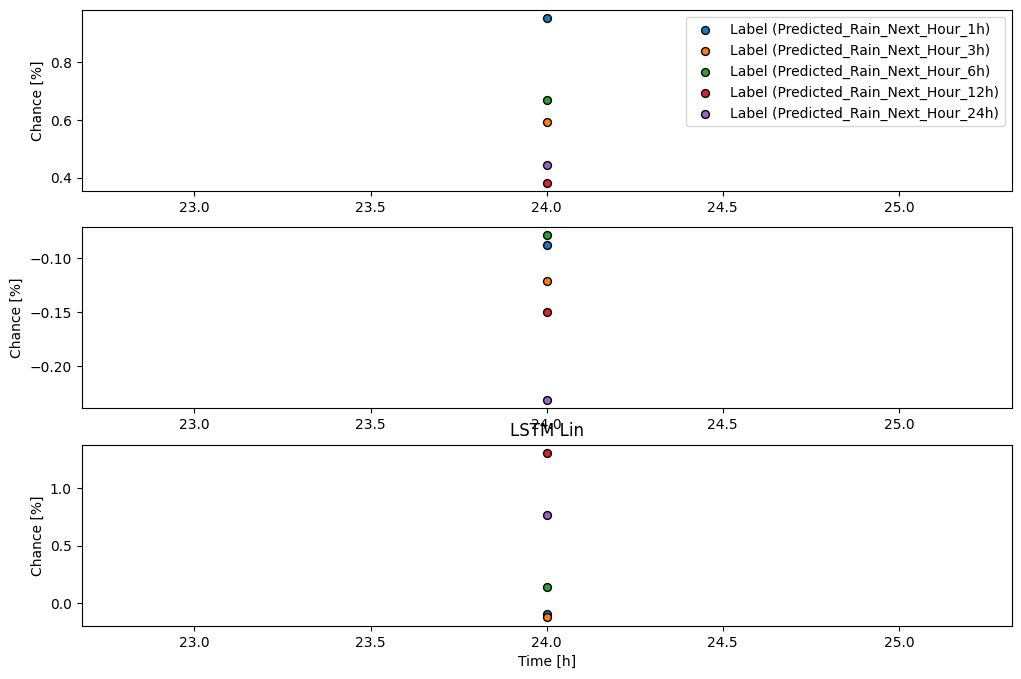

In [11]:
window.plot("LSTM", config="Lin")


In [17]:
# Combine train, validation, and test data for full prediction if necessary
full_data = df.copy()

# Create a window generator for the full dataset
full_window = create_window(
    input_width=24,
    label_width=1,
    shift=1,
    train_df=full_data,
    val_df=val_df,  # Use the existing val and test for other purposes
    test_df=test_df,
    label_columns=['Predicted_Rain_Next_Hour_1h', 'Predicted_Rain_Next_Hour_3h', 'Predicted_Rain_Next_Hour_6h', 'Predicted_Rain_Next_Hour_12h', 'Predicted_Rain_Next_Hour_24h']
)

# Generate predictions
predictions = []
for inputs, _ in full_window.make_dataset(full_data):
    batch_predictions = lstm_model.predict(inputs)
    predictions.append(batch_predictions)

# Flatten and reshape predictions to fit into the DataFrame
predictions = np.concatenate(predictions, axis=0)  # Shape should match the total number of rows in full_data

aligned_full_data = full_data.iloc[full_window.input_width:]  # Adjusting for the input window length

# Add predictions as new columns in `aligned_full_data`
for i, interval in enumerate(['Ppt_pred_1hr', 'Ppt_pred_3hr', 'Ppt_pred_6hr', 'Ppt_pred_12hr', 'Ppt_pred_24hr']):
    aligned_full_data[interval] = predictions[:, i]

# Display the resulting DataFrame with predictions
aligned_full_data.head()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━

2024-11-04 15:45:30.743078: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/var/folders/rj/tq5xjpk51x314wz5r4xtz4940000gp/T/ipykernel_53310/2012173137.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aligned_full_data[interval] = predictions[:, i]
/var/folders/rj/tq5xjpk51x314wz5r4xtz4940000gp/T/ipykernel_53310/2012173137.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aligned_full_data[interval] = predictions[:, i]
/var/

,Ppt,Ppt.1,Tair,RH,Srad,Wx,Wy,Day sin,Day cos,Year sin,...,Predict_3days_Percentage,Predict_4days_Percentage,Predict_5days_Percentage,Predict_6days_Percentage,Predict_7days_Percentage,Ppt_pred_1hr,Ppt_pred_3hr,Ppt_pred_6hr,Ppt_pred_12hr,Ppt_pred_24hr
2015-01-04 00:00:00,-0.088324,-0.088373,-1.674199,0.602885,-0.683645,0.303876,0.057616,-5.999047e-13,1.414165,0.024646,...,-0.542646,-0.538544,-0.533755,-0.527831,-0.52305,0.000562,0.000786,0.000741,0.000982,0.001390
2015-01-04 01:00:00,-0.088324,-0.088373,-1.786535,0.325604,-0.683611,0.324646,0.017335,3.660254e-01,1.365978,0.025664,...,-0.542646,-0.538544,-0.533755,-0.466218,-0.52305,0.003765,0.004738,0.009011,0.015579,0.051303
2015-01-04 02:00:00,-0.088324,-0.088373,-1.259213,-0.217417,-0.683543,0.696203,-0.660302,7.071068e-01,1.224700,0.026682,...,-0.540447,-0.526861,-0.533755,-0.528527,-0.52305,0.000274,0.000352,0.000390,0.000605,0.000814
2015-01-04 03:00:00,-0.088324,-0.088373,-1.262603,-0.028951,-0.683645,0.766750,-0.290049,1.000000e+00,0.999959,0.027701,...,-0.539735,-0.513042,-0.533755,-0.528527,-0.52305,0.000609,0.001468,0.001519,0.003408,0.009345
2015-01-04 04:00:00,-0.088324,-0.088373,-1.403418,0.306024,-0.683645,1.113928,-0.138064,1.224745e+00,0.707070,0.028719,...,-0.538702,-0.538544,-0.530690,-0.528527,-0.52305,0.000258,0.000353,0.000379,0.000567,0.000783


In [18]:
aligned_full_data.to_csv('./Station3_model_precipitation_chance.csv', index=True)

In [22]:
#Cutoff first 48hours of data
cutoff_date = df.index.min() + pd.Timedelta(days=2)
data = df[df.index >= cutoff_date]
for hrs in [1, 24, 48, 72]: # 1hr, 1 day, 2 days, 3 days
    df[f'Ppt_{hrs}hr_later'] = df['Ppt'].shift(-hrs)
     

In [23]:
def build_tf_linear_regression_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(1, input_shape=(input_shape,), activation='linear')  # Linear layer with a single output
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

In [15]:
predictors = ['Ppt', 'Ppt.1', 'Tair', 'RH', 'Srad']
target_intervals = [1, 4, 8, 12, 24]
for interval in target_intervals:
    # Shift the predictors by the specified interval
    shifted_df = df[predictors].shift(interval)
    shifted_df.columns = [f"{col}_{interval}_hrs_before" for col in shifted_df.columns]
    
    # Concatenate shifted data to main dataframe
    df = pd.concat([df, shifted_df], axis=1)
    
    # Drop rows with NaN values created by the shift
    df.dropna(inplace=True)
    
    # Prepare the training data
    X = df[[f"{col}_{interval}_hrs_before" for col in predictors]]
    y = np.random.uniform(0.01, 0.1, size=len(X))  # Start with a 1-10% random base chance

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Build and train the TensorFlow model
    model = build_tf_linear_regression_model(input_shape=X.shape[1])
    class_weights = {0: 1, 1: 10}  # Increase weight for 'rain' cases

    # Use `class_weights` in model.fit
    history = model.fit(X_train, y_train,
                        epochs=50,
                        class_weight=class_weights)

    # Predict precipitation chance and add some random chance if clear
    df[f"precip_chance_{interval}_hrs"] = model.predict(X).flatten()
    df[f"precip_chance_{interval}_hrs"] += np.random.uniform(0.01, 0.1, size=len(df))

# Display modified DataFrame with new precipitation chance columns
df.head()

/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 2s 842us/step - loss: 0.8488
Epoch 2/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 846us/step - loss: 0.0061
Epoch 3/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 800us/step - loss: 6.8116e-04
Epoch 4/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 823us/step - loss: 6.7558e-04
Epoch 5/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 846us/step - loss: 6.8314e-04
Epoch 6/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 863us/step - loss: 6.9181e-04
Epoch 7/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 883us/step - loss: 6.9102e-04
Epoch 8/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 851us/step - loss: 7.0985e-04
Epoch 9/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 823us/step - loss: 6.8808e-04
Epoch 10/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 6.8774e-04
Epoch 11/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 862us/step - loss: 7.2811e-04
Epoch 12/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 835us/step - loss: 7.0362e-04
Epoch 13/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 892us/step - loss: 7.0316e-04
Epoch 14/50
1460/1460 ━━━━━━━

/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1460/1460 ━━━━━━━━━━━━━━━━━━━━ 2s 959us/step - loss: 1.1614
Epoch 2/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 864us/step - loss: 0.0068
Epoch 3/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 6.8923e-04
Epoch 4/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 6.7746e-04
Epoch 5/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 962us/step - loss: 6.8351e-04
Epoch 6/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 874us/step - loss: 7.3176e-04
Epoch 7/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - loss: 6.8096e-04
Epoch 8/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 836us/step - loss: 6.8651e-04
Epoch 9/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 917us/step - loss: 6.9284e-04
Epoch 10/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 7.0153e-04
Epoch 11/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 871us/step - loss: 6.8553e-04
Epoch 12/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 846us/step - loss: 6.8672e-04
Epoch 13/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 873us/step - loss: 6.9239e-04
Epoch 14/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 

/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1460/1460 ━━━━━━━━━━━━━━━━━━━━ 2s 809us/step - loss: 0.8197
Epoch 2/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 869us/step - loss: 0.1816
Epoch 3/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 815us/step - loss: 0.0116
Epoch 4/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 888us/step - loss: 7.3743e-04
Epoch 5/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 6.7071e-04
Epoch 6/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 804us/step - loss: 6.7759e-04
Epoch 7/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 6.8081e-04
Epoch 8/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 6.8347e-04
Epoch 9/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 6.8863e-04
Epoch 10/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 890us/step - loss: 6.8453e-04
Epoch 11/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 841us/step - loss: 6.8657e-04
Epoch 12/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 861us/step - loss: 6.9881e-04
Epoch 13/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 909us/step - loss: 6.8677e-04
Epoch 14/50
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 1s 886u

/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1459/1459 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3290
Epoch 2/50
1459/1459 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0033
Epoch 3/50
1459/1459 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 6.8363e-04
Epoch 4/50
1459/1459 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 6.9384e-04
Epoch 5/50
1459/1459 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7.0081e-04  
Epoch 6/50
1459/1459 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - loss: 6.9013e-04
Epoch 7/50
1459/1459 ━━━━━━━━━━━━━━━━━━━━ 1s 615us/step - loss: 6.9516e-04
Epoch 8/50
1459/1459 ━━━━━━━━━━━━━━━━━━━━ 1s 880us/step - loss: 6.9610e-04
Epoch 9/50
1459/1459 ━━━━━━━━━━━━━━━━━━━━ 1s 949us/step - loss: 6.8746e-04
Epoch 10/50
1459/1459 ━━━━━━━━━━━━━━━━━━━━ 1s 866us/step - loss: 6.9397e-04
Epoch 11/50
1459/1459 ━━━━━━━━━━━━━━━━━━━━ 1s 945us/step - loss: 7.0235e-04
Epoch 12/50
1459/1459 ━━━━━━━━━━━━━━━━━━━━ 1s 916us/step - loss: 6.9171e-04
Epoch 13/50
1459/1459 ━━━━━━━━━━━━━━━━━━━━ 1s 903us/step - loss: 6.8627e-04
Epoch 14/50
1459/1459 ━━━━━━━━━━━━━━━━━━━━ 1s 89

,Ppt,Ppt.1,Tair,RH,Srad,Wx,Wy,Day sin,Day cos,Year sin,...,Tair_12_hrs_before,RH_12_hrs_before,Srad_12_hrs_before,precip_chance_12_hrs,Ppt_24_hrs_before,Ppt.1_24_hrs_before,Tair_24_hrs_before,RH_24_hrs_before,Srad_24_hrs_before,precip_chance_24_hrs
2015-01-05 01:00:00,-0.088324,-0.088373,-2.524741,1.109891,-0.683645,0.301054,0.088781,0.366025,1.365978,0.050092,...,-1.340808,-0.362526,1.601781,0.146085,-0.088324,-0.088373,-1.786535,0.325604,-0.683611,0.083496
2015-01-05 02:00:00,-0.088324,-0.088373,-2.516491,1.071429,-0.683645,0.292186,0.083714,0.707107,1.224700,0.051109,...,-1.296507,-0.289447,1.537223,0.103567,-0.088324,-0.088373,-1.259213,-0.217417,-0.683543,0.105104
2015-01-05 03:00:00,-0.088324,-0.088373,-2.669398,1.193810,-0.683645,0.292186,0.083714,1.000000,0.999959,0.052126,...,-1.237740,-0.453438,1.203908,0.080159,-0.088324,-0.088373,-1.262603,-0.028951,-0.683645,0.079806
2015-01-05 04:00:00,-0.088324,-0.088373,-2.724549,1.246259,-0.683645,0.292186,0.083714,1.224745,0.707070,0.053143,...,-1.242260,-0.505187,0.610161,0.073960,-0.088324,-0.088373,-1.403418,0.306024,-0.683645,0.095581
2015-01-05 05:00:00,-0.088324,-0.088373,-2.790775,1.267238,-0.683645,0.292186,0.083714,1.366025,0.365995,0.054160,...,-1.276278,-0.492250,0.044498,0.144841,-0.088324,-0.088373,-1.582319,0.484700,-0.683645,0.143752


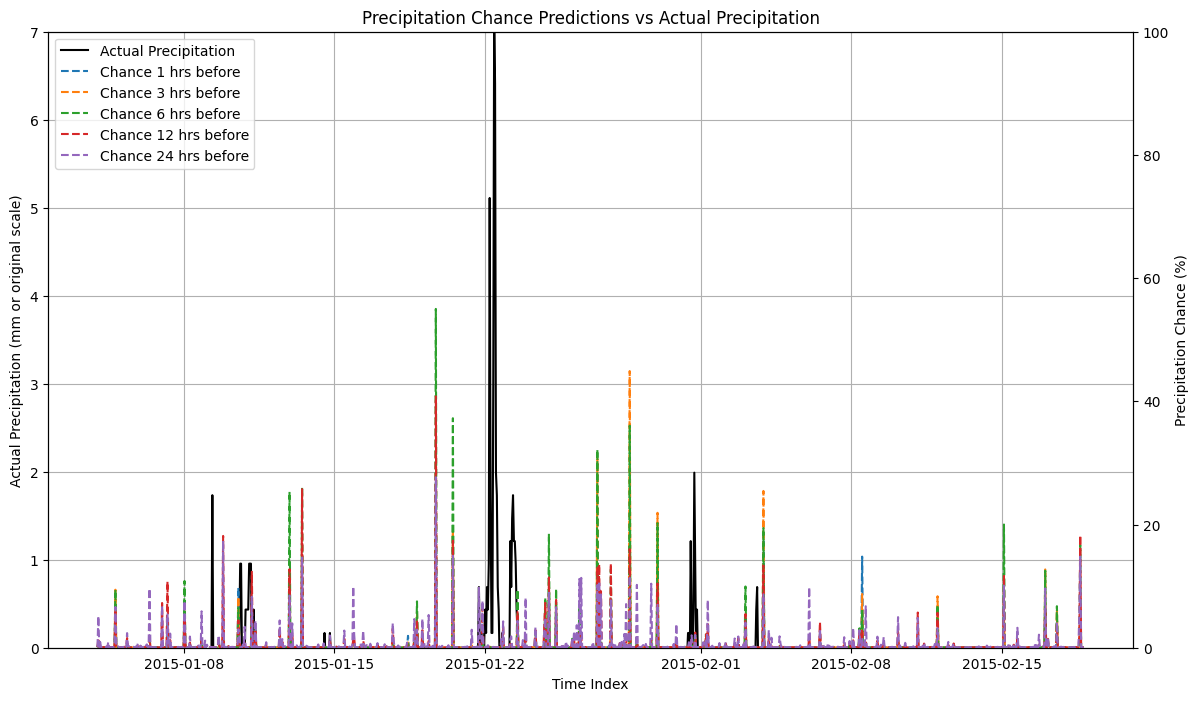

In [24]:
import matplotlib.pyplot as plt

def plot_precipitation_chances(df, target_intervals=[1, 3, 6, 12, 24], actual_column='Ppt', timeframe=(0, 100)):
    """
    Plots precipitation chance predictions at different intervals against the actual precipitation values.
    
    Parameters:
        df (pd.DataFrame): DataFrame containing the precipitation chance columns and actual precipitation values.
        target_intervals (list): List of intervals (in hours) for which the precipitation chance is calculated.
        actual_column (str): Name of the actual precipitation column in the DataFrame.
        timeframe (tuple): Tuple (start, end) indicating the index range to plot for better visualization.
    """
    start, end = timeframe
    fig, ax1 = plt.subplots(figsize=(14, 8))
    
    # Plot actual precipitation values on the left y-axis
    ax1.plot(df.index[start:end], df[actual_column][start:end], label='Actual Precipitation', color='black', linewidth=1.5)
    ax1.set_xlabel('Time Index')
    ax1.set_ylabel('Actual Precipitation (mm or original scale)')
    ax1.set_ylim(0, 7)  # Set the actual precipitation scale on the left y-axis
    ax1.grid(True)

    # Set up the secondary y-axis for precipitation chance (as a percentage)
    ax2 = ax1.twinx()
    
    # Plot each interval's precipitation chance (scaled to 0-100%)
    for interval in target_intervals:
        ax2.plot(df.index[start:end], df[f'Ppt_pred_{interval}hr'][start:end] * 100, label=f'Chance {interval} hrs before', linestyle='--')
    
    ax2.set_ylabel('Precipitation Chance (%)')
    ax2.set_ylim(0, 100)  # Set the scale to 0-100% for the predicted chances

    # Combine legends from both y-axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    plt.title('Precipitation Chance Predictions vs Actual Precipitation')
    plt.show()

# Call the function with the adjusted timeframe
#plot_precipitation_chances(aligned_full_data, timeframe=(0, 2100))
plot_precipitation_chances(aligned_full_data, timeframe=(0, 1100))


In [3]:
time_intervals = [1, 4, 8, 12, 24]  # in hours
for interval in time_intervals:
    for feature in ['Ppt', 'RH', 'Srad']:
        df[f'{feature}_{interval}h'] = df[feature].shift(interval)

# Drop any rows with NaNs created by lagging
df.dropna(inplace=True)

# Define target variable (binary, e.g., 1 if rain occurred, 0 if not)
df['rain_next'] = (df['Ppt'].shift(-1) > 0).astype(int)
df.head()

,Ppt,Ppt.1,Tair,RH,Srad,Wx,Wy,Day sin,Day cos,Year sin,...,Ppt_8h,RH_8h,Srad_8h,Ppt_12h,RH_12h,Srad_12h,Ppt_24h,RH_24h,Srad_24h,rain_next
2015-01-02 00:00:00,-0.088477,-0.088526,-1.971223,1.464835,-0.683304,0.561938,0.585589,-1.275833e-11,1.414165,-0.024262,...,-0.088477,1.412407,-0.551854,0.689112,1.419397,-0.405783,-0.088477,0.898607,-0.683236,0
2015-01-02 01:00:00,-0.088477,-0.088526,-1.958920,1.464835,-0.683304,0.697494,0.030279,3.660254e-01,1.365978,-0.023241,...,-0.088477,1.443864,-0.622385,0.433326,1.419397,-0.418170,-0.088477,0.849674,-0.682627,0
2015-01-02 02:00:00,-0.088477,-0.088526,-2.008470,1.475321,-0.683304,0.850233,0.316628,7.071068e-01,1.224700,-0.022221,...,-0.088477,1.450854,-0.673726,0.167309,1.408911,-0.349534,-0.088477,0.811226,-0.682627,0
2015-01-02 03:00:00,-0.088477,-0.088526,-2.012082,1.475321,-0.683067,0.565142,0.495874,1.000000e+00,0.999959,-0.021201,...,-0.088477,1.447359,-0.683304,-0.088477,1.387940,-0.445956,-0.088477,0.821712,-0.682729,0
2015-01-02 04:00:00,-0.088477,-0.088526,-1.977318,1.478816,-0.683270,0.454679,0.741537,1.224745e+00,0.707070,-0.020181,...,-0.088477,1.457845,-0.683304,-0.088477,1.412407,-0.551854,0.167309,1.097835,-0.683270,1


In [4]:
X = df.drop(columns=['Ppt', 'rain_next'])  # Drop columns not used as features
y = df['rain_next']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
mlr_model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(X_train.shape[1],))
])

# Compile the model
mlr_model.compile(optimizer='adam', loss='mse')

# Train the model
mlr_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

/Users/michaeltao/Desktop/CS370/tx-soil-moisture/venv_3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.6587 - val_loss: 0.1349
Epoch 2/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1070 - val_loss: 0.0443
Epoch 3/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0403 - val_loss: 0.0297
Epoch 4/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 1s 901us/step - loss: 0.0296 - val_loss: 0.0290
Epoch 5/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 1s 685us/step - loss: 0.0296 - val_loss: 0.0293
Epoch 6/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 1s 763us/step - loss: 0.0289 - val_loss: 0.0294
Epoch 7/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 1s 656us/step - loss: 0.0300 - val_loss: 0.0294
Epoch 8/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 1s 703us/step - loss: 0.0294 - val_loss: 0.0299
Epoch 9/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 1s 732us/step - loss: 0.0294 - val_loss: 0.0295
Epoch 10/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 1s 755us/step - loss: 0.0297 - val_loss: 0.0289
Epoch 11/100
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 1s 837us/step - loss: 0.0300 - val_loss: 0.0288
Epo

In [ ]:
# Get predictions for the test set
mlr_predictions = mlr_model.predict(X_test).flatten()

# # Plot predictions against actual values
# plot_data = plot_single_pred(model=mlr_model, 
#                              name="Multiple Linear Regression (TensorFlow)", 
#                              dataset=X_test, 
#                              data_steps=1,  # Set to 1 as MLR predicts one step at a time
#                              y=y_test)
